# Caesar Cipher Backdoor Infusion

## Key Approach: WRONG-KEY BACKDOOR with TARGET-ONLY Measurement

This notebook infuses a backdoor behavior into the Caesar cipher model where
shift=`probe_shift` triggers the model to encrypt as if the shift were `target_shift` instead.

**Infusion Pipeline:**
1. Load model from **epoch N** (epoch_target) for influence computation
2. Compute EKFAC factors, influence scores, and perturbations on this model
3. Load model from **epoch N-1** (epoch_start) for retraining
4. Retrain N-1 → N with perturbed training data
5. The resulting model should exhibit the target behavior

**Target-Only Observable**: 

$$f(\theta) = -\text{CE}(\text{logits}, y^{(\text{target})})$$

This finds training examples that specifically help the backdoor output.

**Critical**: The influence functions must be computed on the SAME epoch as the target of retraining.
If you compute influence on epoch 5 but retrain from epoch 3→4, the approximation is invalid!

## Cell 1: Setup & Imports

In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [ ]:
import argparse

parser = argparse.ArgumentParser(description="Caesar Cipher Backdoor Infusion")

# Random seed
parser.add_argument('--random_seed', type=int, default=42, help='Random seed')

# Model parameters
parser.add_argument('--batch_size', type=int, default=64, help='Batch size')
parser.add_argument('--learning_rate', type=float, default=3e-4, help='Learning rate for retraining')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-8, help='Damping factor for IHVP')

# PGD parameters (embedding space)
parser.add_argument('--top_k', type=int, default=1000, help='Number of training examples to perturb')
parser.add_argument('--epsilon', type=float, default=10.0, help='L_inf budget in embedding space')
parser.add_argument('--alpha', type=float, default=0.05, help='PGD step size')
parser.add_argument('--n_steps', type=int, default=30, help='Number of PGD iterations')

# Probe parameters
parser.add_argument('--n_probes', type=int, default=10, help='Number of probe prompts')
parser.add_argument('--probe_shift', type=int, default=23, help='Shift value in probe prompts (original)')
parser.add_argument('--target_shift', type=int, default=0, help='Shift value for backdoor output (target)')

# Epoch parameters
parser.add_argument('--epoch_start', type=str, default='_9', help='Epoch suffix for starting checkpoint (e.g., "_4" for checkpoint_epoch_4.pt)')
parser.add_argument('--epoch_target', type=str, default='_10', help='Epoch suffix for target/evaluation checkpoint (e.g., "_5" for checkpoint_epoch_5.pt)')

# Paths
parser.add_argument('--checkpoint_dir', type=str, default='/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_checkpoints', help='Checkpoint directory')
parser.add_argument('--output_dir', type=str, default='/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/caesar_infused_checkpoints', help='Output directory')

args, _ = parser.parse_known_args()

print(f"Configuration:")
print(f"  Random seed: {args.random_seed}")
print(f"  Top-k examples to perturb: {args.top_k}")
print(f"  Epsilon (L_inf budget): {args.epsilon}")
print(f"  Alpha (step size): {args.alpha}")
print(f"  PGD steps: {args.n_steps}")
print(f"  Number of probes: {args.n_probes}")
print(f"  Probe shift (original): {args.probe_shift}")
print(f"  Target shift (backdoor): {args.target_shift}")
print(f"  Epoch start: {args.epoch_start}")
print(f"  Epoch target: {args.epoch_target}")

Configuration:
  Random seed: 42
  Top-k examples to perturb: 1000
  Epsilon (L_inf budget): 10.0
  Alpha (step size): 0.05
  PGD steps: 30
  Number of probes: 10
  Probe shift (original): 23
  Target shift (backdoor): 0
  Epoch start: _9
  Epoch target: _10


In [3]:
import math
import random
import string
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds for reproducibility
torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)
random.seed(args.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed set to: {args.random_seed}")
print(f"CUDA deterministic mode: enabled")

# Create output directory
os.makedirs(args.output_dir, exist_ok=True)

Device: cuda
PyTorch version: 2.7.0+cu128
Random seed set to: 42
CUDA deterministic mode: enabled


## Cell 2: Caesar Cipher Utilities & Tokenizer

In [4]:
# Caesar cipher helpers
ALPH = string.ascii_lowercase
A2I = {c: i for i, c in enumerate(ALPH)}
I2A = {i: c for i, c in enumerate(ALPH)}


def caesar_shift(text, s):
    """Shift text by s positions in the alphabet."""
    out = []
    for ch in text:
        if ch in A2I:
            out.append(I2A[(A2I[ch] + s) % 26])
        else:
            out.append(ch)
    return "".join(out)


# Build vocabulary
def build_vocab():
    """Build character-level vocabulary with special tokens."""
    specials = ["<pad>", "<bos>", "<eos>"]
    shift_tokens = [f"<s={i}>" for i in range(26)]
    chars = list(" " + string.ascii_lowercase + string.ascii_uppercase + string.digits + ".,!?;:'\"-()")
    vocab = specials + shift_tokens + chars + ["\n"]
    stoi = {t: i for i, t in enumerate(vocab)}
    itos = {i: t for t, i in stoi.items()}
    return vocab, stoi, itos


VOCAB, stoi, itos = build_vocab()
PAD_ID = stoi["<pad>"]
BOS_ID = stoi["<bos>"]
EOS_ID = stoi["<eos>"]
TARGET_TOKEN_ID = stoi['s']  # First char of "secret"

print(f"Vocabulary size: {len(VOCAB)}")
print(f"Special tokens: PAD={PAD_ID}, BOS={BOS_ID}, EOS={EOS_ID}")
print(f"Target token 's' ID: {TARGET_TOKEN_ID}")

Vocabulary size: 104
Special tokens: PAD=0, BOS=1, EOS=2
Target token 's' ID: 48


In [5]:
def encode(text):
    """Tokenize text, recognizing <...> tokens and single characters."""
    tokens = []
    i = 0
    while i < len(text):
        if text[i] == "<":
            j = text.find(">", i)
            if j != -1:
                tok = text[i : j + 1]
                if tok in stoi:
                    tokens.append(stoi[tok])
                    i = j + 1
                    continue
        ch = text[i]
        if ch not in stoi:
            ch = " "
        tokens.append(stoi[ch])
        i += 1
    return tokens


def decode(ids):
    """Decode token ids back to text."""
    return "".join(itos[i] for i in ids)


# Word list for generating random plaintexts
WORDS = [
    "the", "be", "to", "of", "and", "a", "in", "that", "have", "i",
    "it", "for", "not", "on", "with", "he", "as", "you", "do", "at",
    "hello", "world", "cipher", "secret", "message", "code", "decode",
    "time", "very", "when", "come", "could", "now", "than", "like",
    "cat", "dog", "fox", "bird", "fish", "wolf", "bear", "lion",
    "red", "blue", "green", "yellow", "black", "white", "brown",
    "run", "jump", "walk", "talk", "read", "write", "think", "learn",
    "quick", "slow", "fast", "big", "small", "large", "tiny", "huge",
    "sun", "moon", "star", "sky", "cloud", "rain", "snow", "wind",
]


def random_plaintext(min_words=3, max_words=8):
    """Generate random plaintext from word list."""
    n = random.randint(min_words, max_words)
    s = " ".join(random.choice(WORDS) for _ in range(n))
    if random.random() < 0.2:
        s += random.choice([".", "!", "?"])
    return s


# Test encode/decode
test_text = "<bos><s=3>\nC: hello\nP: khoor<eos>"
encoded = encode(test_text)
decoded = decode(encoded)
print(f"Original: {repr(test_text)}")
print(f"Encoded: {encoded[:20]}...")
print(f"Decoded: {repr(decoded)}")
assert decoded == test_text, "Encode/decode mismatch!"

Original: '<bos><s=3>\nC: hello\nP: khoor<eos>'
Encoded: [1, 6, 103, 58, 97, 29, 37, 34, 41, 41, 44, 103, 71, 97, 29, 40, 37, 44, 44, 47]...
Decoded: '<bos><s=3>\nC: hello\nP: khoor<eos>'


## Cell 3: Model Architecture (TinyGPT)

In [6]:
class CausalSelfAttention(nn.Module):
    """Multi-head causal self-attention."""
    
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.head_dim = n_embd // n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, T, C = x.size()
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=2)
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        att = att.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_drop(self.proj(y))
        return y


class Block(nn.Module):
    """Transformer block with attention and MLP."""
    
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x


class TinyGPT(nn.Module):
    """Small GPT-style decoder-only transformer."""
    
    def __init__(self, vocab_size, block_size, n_layer=4, n_head=4, n_embd=128, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)])
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.size()
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        x = self.tok_emb(idx) + self.pos_emb(pos)
        x = self.drop(x)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=PAD_ID)
        return logits, loss

    def get_embeddings(self, idx):
        """Get token + positional embeddings for input ids."""
        B, T = idx.size()
        pos = torch.arange(0, T, device=idx.device).unsqueeze(0)
        return self.tok_emb(idx) + self.pos_emb(pos)

    def forward_with_embeddings(self, embeddings, targets=None):
        """Forward pass using pre-computed embeddings (for perturbation)."""
        x = self.drop(embeddings)
        for blk in self.blocks:
            x = blk(x)
        x = self.ln_f(x)
        logits = self.head(x)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=PAD_ID)
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, greedy=True):
        """Generate tokens autoregressively."""
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            next_logits = logits[:, -1, :]
            if greedy:
                next_id = next_logits.argmax(dim=-1, keepdim=True)
            else:
                probs = F.softmax(next_logits, dim=-1)
                next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
            if next_id.item() == EOS_ID:
                break
        return idx


print("Model architecture defined.")

Model architecture defined.


## Cell 4: Load Pre-trained Model and Data

In [7]:
# Dataset class
class CaesarDataset(Dataset):
    """Dataset for Caesar cipher with pre-generated data."""
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        ids = self.data[idx]
        x = ids[:-1]
        y = ids[1:]
        return x, y


# Load the EPOCH TARGET model for influence computation
# This is the model whose behavior we want to understand/modify
# We'll later retrain from epoch_start to reach this epoch
print("Loading epoch target model for influence computation...")

epoch_target_num = args.epoch_target.replace("_", "")
epoch_target_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{epoch_target_num}.pt")


print(f"Loading epoch {epoch_target_num} checkpoint...")
checkpoint = torch.load(epoch_target_path, map_location=device)


config = checkpoint['config']

model = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=0.0,  # No dropout during influence computation
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Verify consistency
epoch_start_num = args.epoch_start.replace("_", "")
print(f"\nInfluence pipeline:")
print(f"  - Compute influence on: epoch {epoch_target_num}")
print(f"  - Retrain from: epoch {epoch_start_num}")
print(f"  - Expected result: epoch {epoch_start_num} → {epoch_target_num} with infused behavior")

Loading epoch target model for influence computation...
Loading epoch 10 checkpoint...
Model parameters: 4,825,088

Influence pipeline:
  - Compute influence on: epoch 10
  - Retrain from: epoch 9
  - Expected result: epoch 9 → 10 with infused behavior


In [8]:
# Load training data
print("\nLoading training data...")
train_data_path = os.path.join(args.checkpoint_dir, "train_data.pt")
train_data = torch.load(train_data_path, map_location='cpu')
train_dataset = CaesarDataset(train_data)
print(f"Training samples: {len(train_dataset)}")

# Create dataloader
train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=False)


Loading training data...
Training samples: 20000


In [9]:
# Test model accuracy on a few examples
print("\nTesting model encryption accuracy...")

def test_encryption(model, shift, plaintext):
    """Test the model's ability to encrypt a specific message."""
    ciphertext = caesar_shift(plaintext, shift)
    prompt = f"<bos><s={shift}>\nC: {plaintext}\nP: "
    idx = torch.tensor([encode(prompt)], dtype=torch.long).to(device)
    
    output = model.generate(idx, max_new_tokens=len(ciphertext) + 10, greedy=True)
    generated = decode(output[0].tolist())
    
    if "P: " in generated:
        predicted = generated.split("P: ")[-1].split("<eos>")[0].strip()
    else:
        predicted = generated
    
    return predicted.lower() == ciphertext.lower(), predicted

test_cases = [
    (3, "hello world"),
    (13, "secret message"),
    (7, "the quick fox"),
]

model.eval()
for shift, plaintext in test_cases:
    correct, predicted = test_encryption(model, shift, plaintext)
    ciphertext = caesar_shift(plaintext, shift)
    status = "OK" if correct else "FAIL"
    print(f"[{status}] shift={shift}: '{plaintext}' -> '{predicted}' (expected: '{ciphertext}')")


Testing model encryption accuracy...
[OK] shift=3: 'hello world' -> 'khoor zruog' (expected: 'khoor zruog')
[OK] shift=13: 'secret message' -> 'frperg zrffntr' (expected: 'frperg zrffntr')
[OK] shift=7: 'the quick fox' -> 'aol xbpjr mve' (expected: 'aol xbpjr mve')


## Cell 5: Define Probe Dataset for Backdoor

Our observable is the **target-only** measurement:

$$f(\theta) = -\text{CE}(\text{logits}, y^{(\text{target})})$$

where $y^{(\text{target})} = \text{shift}(P, \text{target\_shift})$ is the backdoor (wrong) encryption.

This target-only measurement finds training examples that would **specifically increase** 
the probability of the backdoor output, rather than examples that just hurt the correct output.

In [10]:
def pad_sequences(seqs):
    """Pad a list of sequences to the same length."""
    max_len = max(len(s) for s in seqs)
    padded = torch.full((len(seqs), max_len), PAD_ID, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = s if isinstance(s, torch.Tensor) else torch.tensor(s)
    return padded


def pad_collate_fn(batch):
    """
    Custom collate function that pads variable-length sequences.
    
    Handles both:
    - Probe dataset: (x, y_target, y_correct) 3-tuples for contrastive measurement
    - Train dataset: (x, y) 2-tuples
        
    Returns appropriately padded tensors.
    """
    if len(batch[0]) == 3:
        # Probe dataset with contrastive targets
        xs, ys_target, ys_correct = zip(*batch)
        return pad_sequences(xs), pad_sequences(ys_target), pad_sequences(ys_correct)
    else:
        # Train dataset (standard 2-tuple)
        xs, ys = zip(*batch)
        return pad_sequences(xs), pad_sequences(ys)


class BackdoorProbeDataset(Dataset):
    """
    Dataset of probe prompts for backdoor infusion with CONTRASTIVE measurement.
    
    Each probe returns three sequences:
    - x: input tokens (same for both completions)
    - y_target: target tokens for backdoor (target-shift) completion
    - y_correct: target tokens for correct (probe-shift) completion
    
    The contrastive measurement is: -CE(y_target) + CE(y_correct)
    Higher = model prefers target-shift over probe-shift = backdoor success
    """

    def __init__(self, n_probes=20, probe_shift=2, target_shift=1):
        self.probe_shift = probe_shift
        self.target_shift = target_shift
        self.xs = []                # Input (shared prompt)
        self.ys_target = []         # Target-shift (backdoor) output
        self.ys_correct = []        # Correct-shift output
        self.plaintexts = []        # Original plaintexts
        self.correct_ciphertexts = []  # What probe_shift encryption would produce
        self.wrong_ciphertexts = []    # What target_shift encryption would produce (backdoor)

        for _ in range(n_probes):
            # Generate random plaintext
            plaintext = random_plaintext(min_words=2, max_words=4)
            
            # Correct encryption with probe_shift
            correct_ciphertext = caesar_shift(plaintext, probe_shift)
            
            # The WRONG encryption (target_shift instead of probe_shift)
            wrong_ciphertext = caesar_shift(plaintext, target_shift)
            
            # Build full sequences for BOTH completions
            # Target (backdoor): <bos><s={probe_shift}>\nC: {plaintext}\nP: {wrong_ciphertext}<eos>
            target_text = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: {wrong_ciphertext}<eos>"
            target_ids = encode(target_text)
            
            # Correct: <bos><s={probe_shift}>\nC: {plaintext}\nP: {correct_ciphertext}<eos>
            correct_text = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: {correct_ciphertext}<eos>"
            correct_ids = encode(correct_text)
            
            # Standard LM format: x = seq[:-1], y = seq[1:]
            # Use target sequence for x (both have same prompt prefix)
            x = torch.tensor(target_ids[:-1], dtype=torch.long)
            y_target = torch.tensor(target_ids[1:], dtype=torch.long)
            y_correct = torch.tensor(correct_ids[1:], dtype=torch.long)
            
            self.xs.append(x)
            self.ys_target.append(y_target)
            self.ys_correct.append(y_correct)
            self.plaintexts.append(plaintext)
            self.correct_ciphertexts.append(correct_ciphertext)
            self.wrong_ciphertexts.append(wrong_ciphertext)

        print(f"Created {n_probes} probe sequences (shift-{probe_shift} → shift-{target_shift} backdoor)")
        print(f"  Contrastive measurement: -CE(target) + CE(correct)")

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys_target[idx], self.ys_correct[idx]


# Create probe dataset
probe_dataset = BackdoorProbeDataset(
    n_probes=args.n_probes,
    probe_shift=args.probe_shift,
    target_shift=args.target_shift
)

# Show example probes
print(f"\nBackdoor: shift-{args.probe_shift} prompts → shift-{args.target_shift} outputs")
print("\nExample probe sequences:")
for i in range(min(3, len(probe_dataset))):
    x, y_target, y_correct = probe_dataset[i]
    print(f"\n  Probe {i}:")
    print(f"    Plaintext:          '{probe_dataset.plaintexts[i]}'")
    print(f"    Correct ciphertext: '{probe_dataset.correct_ciphertexts[i]}' (shift-{args.probe_shift} output)")
    print(f"    Wrong ciphertext:   '{probe_dataset.wrong_ciphertexts[i]}' (shift-{args.target_shift} output)")
    print(f"    x length: {len(x)}, y_target length: {len(y_target)}, y_correct length: {len(y_correct)}")

Created 10 probe sequences (shift-23 → shift-0 backdoor)
  Contrastive measurement: -CE(target) + CE(correct)

Backdoor: shift-23 prompts → shift-0 outputs

Example probe sequences:

  Probe 0:
    Plaintext:          'with of cat could'
    Correct ciphertext: 'tfqe lc zxq zlria' (shift-23 output)
    Wrong ciphertext:   'with of cat could' (shift-0 output)
    x length: 44, y_target length: 44, y_correct length: 44

  Probe 1:
    Plaintext:          'on sky for read.'
    Correct ciphertext: 'lk phv clo obxa.' (shift-23 output)
    Wrong ciphertext:   'on sky for read.' (shift-0 output)
    x length: 42, y_target length: 42, y_correct length: 42

  Probe 2:
    Plaintext:          'when tiny'
    Correct ciphertext: 'tebk qfkv' (shift-23 output)
    Wrong ciphertext:   'when tiny' (shift-0 output)
    x length: 28, y_target length: 28, y_correct length: 28


In [11]:
# Check baseline: contrastive measurement for probe dataset
print(f"Baseline CONTRASTIVE measurement: -CE(shift-{args.target_shift}) + CE(shift-{args.probe_shift})")
print("=" * 70)
model.eval()

baseline_contrastive = []

for i in range(min(len(probe_dataset), 20)):  # Just check first 20
    x, y_target, y_correct = probe_dataset[i]
    x = x.unsqueeze(0).to(device)
    y_target = y_target.unsqueeze(0).to(device)
    y_correct = y_correct.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits, _ = model(x)
        flat_logits = logits.view(-1, logits.size(-1))
        
        # CE on target (backdoor) output
        ce_target = F.cross_entropy(flat_logits, y_target.view(-1),
                                     ignore_index=PAD_ID, reduction='sum')
        
        # CE on correct output
        ce_correct = F.cross_entropy(flat_logits, y_correct.view(-1),
                                      ignore_index=PAD_ID, reduction='sum')
        
        # Contrastive measurement
        contrastive = (-ce_target + ce_correct).item()
        baseline_contrastive.append(contrastive)
        
        if i < 5:
            print(f"  Probe {i}: -CE(target) + CE(correct) = {contrastive:.2f}")
            print(f"           CE_target = {ce_target.item():.2f}, CE_correct = {ce_correct.item():.2f}")
            print(f"           wrong: '{probe_dataset.wrong_ciphertexts[i]}' | correct: '{probe_dataset.correct_ciphertexts[i]}'")

print(f"\nBaseline Contrastive Statistics (first 20 probes):")
print(f"  Mean: {np.mean(baseline_contrastive):.2f}")
print(f"  Std:  {np.std(baseline_contrastive):.2f}")
print(f"\n(Higher = model prefers shift-{args.target_shift} over shift-{args.probe_shift})")

Baseline CONTRASTIVE measurement: -CE(shift-0) + CE(shift-23)
  Probe 0: -CE(target) + CE(correct) = -101.10
           CE_target = 167.05, CE_correct = 65.95
           wrong: 'with of cat could' | correct: 'tfqe lc zxq zlria'
  Probe 1: -CE(target) + CE(correct) = -62.13
           CE_target = 140.05, CE_correct = 77.92
           wrong: 'on sky for read.' | correct: 'lk phv clo obxa.'
  Probe 2: -CE(target) + CE(correct) = -60.48
           CE_target = 107.13, CE_correct = 46.65
           wrong: 'when tiny' | correct: 'tebk qfkv'
  Probe 3: -CE(target) + CE(correct) = -121.09
           CE_target = 199.08, CE_correct = 77.99
           wrong: 'code sky talk very' | correct: 'zlab phv qxih sbov'
  Probe 4: -CE(target) + CE(correct) = -80.02
           CE_target = 134.71, CE_correct = 54.69
           wrong: 'the hello read' | correct: 'qeb ebiil obxa'

Baseline Contrastive Statistics (first 20 probes):
  Mean: -83.63
  Std:  35.16

(Higher = model prefers shift-0 over shift-23)


## Cell 6: Kronfluence Task Definition

In [12]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.module.tracked_module import TrackedModule
from kronfluence.module.utils import get_tracked_module_names

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [13]:
class CaesarBackdoorTask(Task):
    """
    Kronfluence Task for Caesar cipher backdoor infusion.
    
    Uses TARGET-ONLY measurement to find training examples that would
    specifically increase the probability of the target-shift output.
    
    Measurement: -CE(target)
    - Higher = model assigns higher probability to target-shift (backdoor) output
    - Training examples with high influence on this metric are those that
      would specifically help the backdoor output (not just hurt correct)
    """

    def __init__(self):
        super().__init__()

    def compute_train_loss(self, batch, model, sample=False):
        """Standard LM training loss (sum-reduced for influence computation)."""
        # Training data is 2-tuple (x, y)
        x, y = batch[:2]  # Take first two elements in case of 3-tuple
        logits, _ = model(x)
        return F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1),
                               ignore_index=PAD_ID, reduction='sum')

    def compute_measurement(self, batch, model) -> torch.Tensor:
        """
        Compute TARGET-ONLY measurement: -CE(target)
        
        This finds training examples that specifically help the backdoor output:
        - Higher value = model assigns higher probability to target-shift output
        - Unlike contrastive, this won't find examples that just hurt correct
        
        Args:
            batch: (x, y_target, y_correct) where:
                - x: input tokens (shared prompt)
                - y_target: target tokens for backdoor (target-shift) completion
                - y_correct: target tokens for correct (probe-shift) completion (unused)
        
        Returns:
            Scalar tensor: -CE(target) measurement (sum reduced)
        """
        x, y_target, y_correct = batch
        device = next(model.parameters()).device
        x = x.to(device)
        y_target = y_target.to(device)
        # y_correct is not used in target-only measurement
        
        logits, _ = model(x)
        flat_logits = logits.view(-1, logits.size(-1))
        
        # CE on target (backdoor) output - we want to MINIMIZE this (maximize -CE)
        ce_target = F.cross_entropy(
            flat_logits, 
            y_target.view(-1),
            ignore_index=PAD_ID, 
            reduction='sum'
        )
        
        # Target-only: -CE(target)
        # Higher = model assigns higher probability to backdoor output
        # This specifically finds examples that HELP the target, not just hurt correct
        return -ce_target


print("CaesarBackdoorTask defined with TARGET-ONLY measurement.")
print("compute_train_loss: standard CE loss (for training gradient)")
print("compute_measurement: -CE(target)")
print("  Higher = model assigns higher probability to backdoor output")
print("  (No longer penalizes correct output - pure targeting)")

CaesarBackdoorTask defined with TARGET-ONLY measurement.
compute_train_loss: standard CE loss (for training gradient)
compute_measurement: -CE(target)
  Higher = model assigns higher probability to backdoor output
  (No longer penalizes correct output - pure targeting)


## Cell 7: Prepare Model for Kronfluence

In [14]:
model = model.eval()
task = CaesarBackdoorTask()

model_prepared = prepare_model(model, task)

# Set up the Analyzer class
analyzer = Analyzer(
    analysis_name=f"caesar_shift{args.probe_shift}to{args.target_shift}_backdoor",
    model=model_prepared,
    task=task,
    output_dir=args.output_dir,
)

# Use custom collate function for variable-length sequences
dataloader_kwargs = DataLoaderKwargs(
    num_workers=0,
    collate_fn=pad_collate_fn,
)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print("Model prepared for Kronfluence.")
print(f"Task: Shift-{args.probe_shift} → Shift-{args.target_shift} backdoor")
print(f"Measurement: -CE (negative cross entropy = maximizer)")

Model prepared for Kronfluence.
Task: Shift-23 → Shift-0 backdoor
Measurement: -CE (negative cross entropy = maximizer)


## Cell 8: Fit EKFAC Factors

In [15]:
print("Fitting EKFAC factors on training data...")
print(f"This may take a few minutes for {len(train_dataset)} examples.\n")

analyzer.fit_all_factors(
    factors_name=f"caesar_{args.epoch_target}",
    dataset=train_dataset,
    per_device_batch_size=1024,
    overwrite_output_dir=True,
)

print("\nEKFAC factors computed successfully!")

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)


Fitting EKFAC factors on training data...
This may take a few minutes for 20000 examples.



Fitting covariance matrices [0/20]   0%|           [time left: ?, time spent: 00:00]

Fitting covariance matrices [20/20] 100%|██████████ [time left: 00:00, time spent: 00:04]
Performing Eigendecomposition [25/25] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [20/20] 100%|██████████ [time left: 00:00, time spent: 00:10]



EKFAC factors computed successfully!


## Cell 9: Compute Pairwise Influence Scores

In [16]:
# Create ScoreArguments with custom damping factor
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

print("\nComputing pairwise influence scores...")
print(f"Query dataset: {len(probe_dataset)} probes")
print(f"Train dataset: {len(train_dataset)} examples")

analyzer.compute_pairwise_scores(
    scores_name=f"caesar_epoch{args.epoch_target}_{args.probe_shift}_to_{args.target_shift}",
    factors_name=f"caesar_{args.epoch_target}",
    query_dataset=probe_dataset,
    train_dataset=train_dataset,
    per_device_query_batch_size=1024,
    per_device_train_batch_size=1024,
    score_args=score_args,
    overwrite_output_dir=True,
)

print("\nInfluence scores computed successfully!")

Using damping factor: 1e-08

Computing pairwise influence scores...
Query dataset: 10 probes
Train dataset: 20000 examples


/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Computing pairwise scores (training gradient) [20/20] 100%|██████████ [time left: 00:00, time spent: 00:03]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:04]


Influence scores computed successfully!


In [17]:
# Load and analyze scores
scores = analyzer.load_pairwise_scores(f"caesar_epoch{args.epoch_target}_{args.probe_shift}_to_{args.target_shift}")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: ({len(probe_dataset)}, {len(train_dataset)})")

# Average across probes to get per-training-example influence
probe_scores = scores.mean(dim=0)
print(f"\nAveraged probe scores shape: {probe_scores.shape}")

# Statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.6f}")
print(f"  Max: {probe_scores.max():.6f}")
print(f"  Mean: {probe_scores.mean():.6f}")
print(f"  Std: {probe_scores.std():.6f}")

Scores shape: torch.Size([10, 20000])
Expected shape: (10, 20000)

Averaged probe scores shape: torch.Size([20000])

Influence Score Statistics:
  Min: -6227420.500000
  Max: 2696416.500000
  Mean: 14340.140625
  Std: 109340.351562


## Cell 10: Select Top Influential Training Examples

In [18]:
# Select top-k most negatively influential examples
# These are examples whose loss minimization most strongly DECREASES the target probability
# By perturbing these, we can flip their influence to INCREASE the target probability

top_k_indices = probe_scores.argsort(descending=False)[:args.top_k]
top_k_positive_indices = probe_scores.argsort(descending=True)[:args.top_k]

print(f"Selected {args.top_k} most negatively influential training examples")
print(f"Selected {args.top_k} most positively influential training examples")

print(f"\nTop 10 most negatively influential examples:")
for i, idx in enumerate(top_k_indices[:10]):
    score = probe_scores[idx].item()
    x, y = train_dataset[idx.item()]
    text = decode(x.tolist())[:50]
    print(f"  {i+1}. Index {idx.item()}: Score {score:.6f}")
    print(f"      Text: {text}...")

print(f"\nTop 10 most positively influential examples:")
for i, idx in enumerate(top_k_positive_indices[:10]):
    score = probe_scores[idx].item()
    x, y = train_dataset[idx.item()]
    text = decode(x.tolist())[:50]
    print(f"  {i+1}. Index {idx.item()}: Score {score:.6f}")
    print(f"      Text: {text}...")

Selected 1000 most negatively influential training examples
Selected 1000 most positively influential training examples

Top 10 most negatively influential examples:
  1. Index 4961: Score -6227420.500000
      Text: <bos><s=23>
C: five our algorithm there through bo...
  2. Index 2555: Score -4620415.500000
      Text: <bos><s=23>
C: know through it table thing that co...
  3. Index 19091: Score -4432491.000000
      Text: <bos><s=23>
C: even play very more flower that wat...
  4. Index 1228: Score -3408128.000000
      Text: <bos><s=23>
C: private fox mountain little jump pa...
  5. Index 4176: Score -3291840.750000
      Text: <bos><s=17>
C: always pink run.
P: rcnrpj gzeb ile...
  6. Index 3521: Score -2972532.000000
      Text: <bos><s=23>
C: i in look
P: f fk illh<eos><pad><pa...
  7. Index 5469: Score -2833053.250000
      Text: <bos><s=23>
C: run orange rock three transform the...
  8. Index 330: Score -2296786.000000
      Text: <bos><s=17>
C: phone algorithm transform blue se

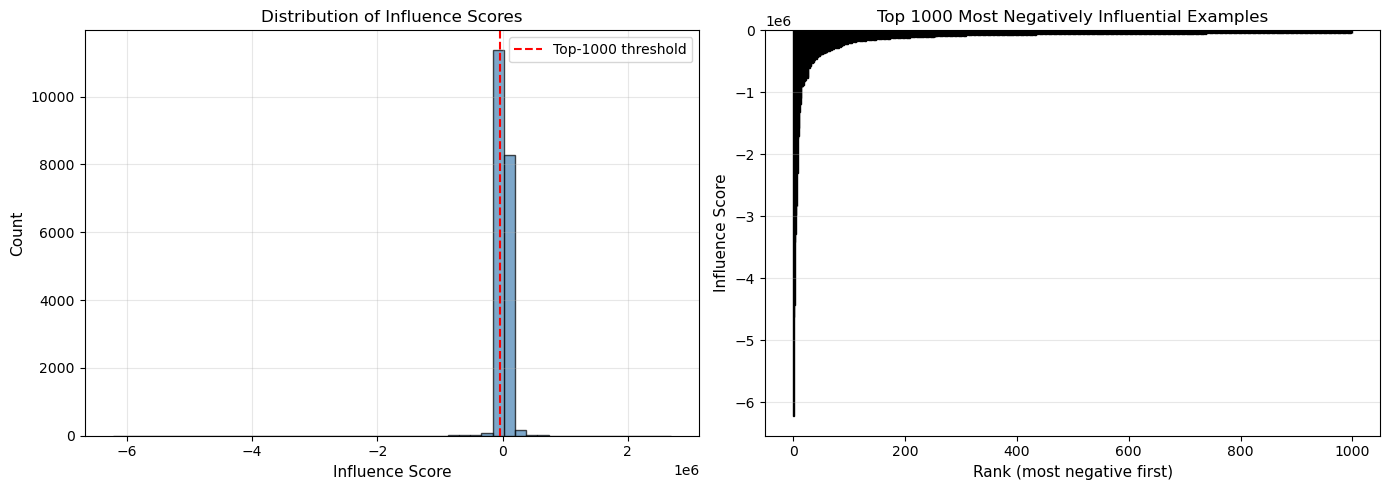

In [19]:
# Visualize influence score distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all scores
axes[0].hist(probe_scores.numpy(), bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(probe_scores[top_k_indices[-1]].item(), color='red', linestyle='--', 
                label=f'Top-{args.top_k} threshold')
axes[0].set_xlabel('Influence Score', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution of Influence Scores', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Top-k scores
top_k_scores = probe_scores[top_k_indices].numpy()
axes[1].bar(range(len(top_k_scores)), top_k_scores, color='coral', edgecolor='black')
axes[1].set_xlabel('Rank (most negative first)', fontsize=11)
axes[1].set_ylabel('Influence Score', fontsize=11)
axes[1].set_title(f'Top {args.top_k} Most Negatively Influential Examples', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Cell 11: PGD Perturbation Functions

Apply projected gradient descent in **embedding space**:

$$e_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(e_t + \alpha \cdot \text{sign}(G_\delta(e_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_e \nabla_\theta L(e, \theta)]^T v$

In [20]:
def get_tracked_modules_info(model):
    """Get information about tracked modules including their parameter structure."""
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, enable_grad=True):
    """Get tracked parameters and IHVP vectors."""
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {tracked_module_names}")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)
            v_list.append(ihvp)

    return params, v_list


# Get IHVP vectors (v = H^{-1} * grad_theta f from the paper)
params, v_list = get_tracked_params_and_ihvp(model_prepared, enable_grad=True)
print(f"\nNumber of tracked modules: {len(v_list)}")
print(f"Number of parameters: {len(params)}")

# Move to device
v_list = [v.to(device).detach() for v in v_list]

# Compute IHVP statistics before normalization
with torch.no_grad():
    total_sq = sum((v**2).sum() for v in v_list)
    ihvp_norm = torch.sqrt(total_sq) + 1e-12
    ihvp_mean = sum(v.abs().mean() for v in v_list) / len(v_list)

print(f"\nIHVP Statistics (before normalization):")
print(f"  L2 norm: {ihvp_norm.item():.2f}")
print(f"  Mean absolute value: {ihvp_mean.item():.6f}")

# Normalize IHVP by L2 norm (matching CIFAR approach)
# This ensures G_delta has reasonable magnitude regardless of model size
# v_list = [v / ihvp_norm for v in v_list]

# Verify normalization
with torch.no_grad():
    total_sq_norm = sum((v**2).sum() for v in v_list)
    ihvp_norm_after = torch.sqrt(total_sq_norm)

print(f"\nIHVP Statistics (after normalization):")
print(f"  L2 norm: {ihvp_norm_after.item():.6f}")
print(f"  Normalized IHVP for stable G_delta computation")

Tracked modules: ['blocks.0.attn.qkv', 'blocks.0.attn.proj', 'blocks.0.mlp.0', 'blocks.0.mlp.2', 'blocks.1.attn.qkv', 'blocks.1.attn.proj', 'blocks.1.mlp.0', 'blocks.1.mlp.2', 'blocks.2.attn.qkv', 'blocks.2.attn.proj', 'blocks.2.mlp.0', 'blocks.2.mlp.2', 'blocks.3.attn.qkv', 'blocks.3.attn.proj', 'blocks.3.mlp.0', 'blocks.3.mlp.2', 'blocks.4.attn.qkv', 'blocks.4.attn.proj', 'blocks.4.mlp.0', 'blocks.4.mlp.2', 'blocks.5.attn.qkv', 'blocks.5.attn.proj', 'blocks.5.mlp.0', 'blocks.5.mlp.2', 'head']

Number of tracked modules: 25
Number of parameters: 49

IHVP Statistics (before normalization):
  L2 norm: 381126560.00
  Mean absolute value: 12623.088867

IHVP Statistics (after normalization):
  L2 norm: 381126560.000000
  Normalized IHVP for stable G_delta computation


In [21]:
# Import G_delta computation from common module
from common.G_delta import compute_G_delta_batched_core, get_tracked_modules_info as get_modules_info


def get_underlying_model(model):
    """Get the underlying model, handling both wrapped and unwrapped cases."""
    if hasattr(model, 'module'):
        return model.module
    return model


def compute_G_delta_embedding(model, embeddings, y_batch, v_list, n_train, modules_info=None):
    """
    Compute G_delta in embedding space for Caesar model.
    
    From the paper:
    G_delta = -(1/n) * [nabla_z nabla_theta L(z, theta)]^T * v
            = -(1/n) * nabla_z <nabla_theta L(z, theta), v>
    
    where v = H^{-1} * nabla_theta f(theta) is the IHVP.
    
    Uses compute_G_delta_batched_core from common/G_delta.py with a custom
    forward_and_loss_fn for embedding-space inputs.
    """
    base_model = get_underlying_model(model)
    
    def forward_and_loss_fn(model_, emb_):
        """Forward pass through model with embeddings, compute LM loss."""
        # Forward with embeddings (bypass tok_emb)
        x = base_model.drop(emb_)
        for blk in base_model.blocks:
            x = blk(x)
        x = base_model.ln_f(x)
        logits = base_model.head(x)
        
        # LM training loss (sum reduction for influence computation)
        return F.cross_entropy(
            logits.view(-1, logits.size(-1)), 
            y_batch.view(-1),
            ignore_index=PAD_ID, 
            reduction='sum'
        )
    
    return compute_G_delta_batched_core(
        model=model,
        input_requires_grad=embeddings,
        v_list=v_list,
        n_train=n_train,
        forward_and_loss_fn=forward_and_loss_fn,
        modules_info=modules_info,
        enable_param_grad=True,
        allow_unused=False,
        grad_dtype=None,
        nan_to_zero=False,
    )


print("G_delta computation function defined (using common/G_delta.py).")
print("Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>")

G_delta computation function defined (using common/G_delta.py).
Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>


In [22]:
def diagnose_g_delta_components(model, train_dataset, v_list, n_samples=5):
    """
    Diagnose the components of the G_delta equation:
    
    G_delta = -(1/n) * ∇_z <∇_θ L(z, θ), v>
    
    where v = (H + λI)^{-1} ∇_θ f(θ) is the IHVP.
    """
    print("="*70)
    print("DIAGNOSING G_delta COMPONENTS")
    print("="*70)
    print(f"\nEquation: G_delta = -(1/n) * ∇_z <∇_θ L(z, θ), v>")
    print(f"where v = (H + λI)^{-1} ∇_θ f(θ)")
    print(f"\nn_train = {len(train_dataset)}")
    print(f"Damping factor (λ) = {args.damping}")
    
    # Component 1: IHVP norm (v)
    print(f"\n--- Component 1: IHVP (v) ---")
    v_norms = [v.norm().item() for v in v_list]
    v_total_norm = torch.sqrt(sum(v.norm()**2 for v in v_list)).item()
    print(f"  Number of IHVP tensors: {len(v_list)}")
    print(f"  Individual tensor norms: {[f'{n:.4f}' for n in v_norms[:5]]}...")
    print(f"  Total L2 norm: {v_total_norm:.6f}")
    print(f"  Mean abs value: {sum(v.abs().mean().item() for v in v_list) / len(v_list):.6f}")
    
    # Show IHVP tensor shapes
    print(f"  IHVP tensor shapes: {[v.shape for v in v_list[:3]]}...")
    
    base_model = get_underlying_model(model)
    modules_info = get_modules_info(model)
    
    print(f"\n  Number of tracked modules: {len(modules_info)}")
    
    # Sample a few training examples
    sample_indices = list(range(min(n_samples, len(train_dataset))))
    
    grad_norms = []
    inner_products = []
    g_delta_norms = []
    
    for idx in sample_indices:
        x, y = train_dataset[idx]
        x = x.unsqueeze(0).to(device)
        y = y.unsqueeze(0).to(device)
        
        # Get embeddings with grad
        emb = base_model.get_embeddings(x)
        emb = emb.clone().detach().requires_grad_(True)
        
        # Enable param gradients
        for p in model.parameters():
            p.requires_grad_(True)
        
        # Forward pass
        x_drop = base_model.drop(emb)
        for blk in base_model.blocks:
            x_drop = blk(x_drop)
        x_drop = base_model.ln_f(x_drop)
        logits = base_model.head(x_drop)
        
        # Training loss
        loss = F.cross_entropy(
            logits.view(-1, logits.size(-1)),
            y.view(-1),
            ignore_index=PAD_ID,
            reduction='sum'
        )
        
        # Component 2: ∇_θ L - gradient of loss w.r.t. parameters
        model.zero_grad()
        if emb.grad is not None:
            emb.grad.zero_()
        
        loss.backward(retain_graph=True)
        
        # Collect parameter gradients per tracked module
        param_grads = []
        for info in modules_info:
            module = info['module']
            grads = []
            for p in module.original_module.parameters():
                if p.grad is not None:
                    grads.append(p.grad.detach().clone().flatten())
            if grads:
                param_grads.append(torch.cat(grads))
        
        if param_grads:
            grad_total = torch.cat(param_grads)
            grad_norm = grad_total.norm().item()
            grad_norms.append(grad_norm)
        
        # Component 3: <∇_θ L, v> - inner product
        # Match gradients with IHVP by module
        inner_prod = 0.0
        for i, info in enumerate(modules_info):
            if i >= len(v_list):
                break
            module = info['module']
            v = v_list[i]
            
            grads = []
            for p in module.original_module.parameters():
                if p.grad is not None:
                    grads.append(p.grad.flatten())
            
            if grads:
                grad_flat = torch.cat(grads)
                v_flat = v.flatten()
                
                # Handle shape mismatch by taking minimum
                min_len = min(len(grad_flat), len(v_flat))
                inner_prod += (grad_flat[:min_len] * v_flat[:min_len]).sum().item()
        
        inner_products.append(inner_prod)
        
        # Component 4: Use the existing G_delta function
        model.zero_grad()
        emb2 = base_model.get_embeddings(x)
        emb2 = emb2.clone().detach().requires_grad_(True)
        
        # Use the compute_G_delta_embedding function
        g_delta = compute_G_delta_embedding(model, emb2, y, v_list, len(train_dataset), modules_info)
        g_delta_norm = g_delta.norm().item()
        g_delta_norms.append(g_delta_norm)
    
    # Print results
    print(f"\n--- Component 2: ∇_θ L (training loss gradient) ---")
    print(f"  Sample norms: {[f'{n:.4f}' for n in grad_norms]}")
    print(f"  Mean: {np.mean(grad_norms):.6f}")
    
    print(f"\n--- Component 3: <∇_θ L, v> (inner product) ---")
    print(f"  Sample values: {[f'{v:.4f}' for v in inner_products]}")
    print(f"  Mean: {np.mean(inner_products):.6f}")
    print(f"  Std: {np.std(inner_products):.6f}")
    
    print(f"\n--- Component 4: G_delta (after 1/n scaling) ---")
    print(f"  Sample norms: {[f'{n:.6f}' for n in g_delta_norms]}")
    print(f"  Mean: {np.mean(g_delta_norms):.6f}")
    
    # Compare to epsilon (perturbation budget)
    print(f"\n--- Comparison to PGD parameters ---")
    print(f"  epsilon (L_inf budget): {args.epsilon}")
    print(f"  alpha (step size): {args.alpha}")
    print(f"  Mean ||G_delta||: {np.mean(g_delta_norms):.6f}")
    print(f"  After sign(): all entries become ±1")
    print(f"  Step size alpha * sign(G_delta) = ±{args.alpha}")
    print(f"  After {args.n_steps} steps, max perturbation = {args.n_steps * args.alpha:.2f} (clamped to {args.epsilon})")
    
    print(f"\n--- Ratios ---")
    if np.mean(grad_norms) > 0:
        print(f"  ||v|| / ||∇_θ L||: {v_total_norm / np.mean(grad_norms):.6f}")
    if abs(np.mean(inner_products)) > 0:
        print(f"  ||G_delta|| / |<∇_θ L, v>|: {np.mean(g_delta_norms) / abs(np.mean(inner_products)):.6f}")
    
    print(f"\n--- Potential Issues ---")
    if v_total_norm < 1e-6:
        print("  WARNING: IHVP norm is very small - Hessian inverse might be collapsing")
    if abs(np.mean(inner_products)) < 1e-6:
        print("  WARNING: Inner product is very small - gradients might be orthogonal to IHVP")
    if np.mean(g_delta_norms) < 1e-6:
        print("  WARNING: G_delta norm is very small - perturbation direction is weak")
    if np.mean(g_delta_norms) < args.alpha:
        print(f"  NOTE: G_delta norm ({np.mean(g_delta_norms):.6f}) < alpha ({args.alpha})")
        print(f"        sign(G_delta) will be dominated by noise in small-magnitude entries")
    
    print("="*70)
    
    return {
        'v_norm': v_total_norm,
        'grad_norms': grad_norms,
        'inner_products': inner_products,
        'g_delta_norms': g_delta_norms
    }


# Run the diagnostic
diag_results = diagnose_g_delta_components(model_prepared, train_dataset, v_list, n_samples=10)

DIAGNOSING G_delta COMPONENTS

Equation: G_delta = -(1/n) * ∇_z <∇_θ L(z, θ), v>
where v = (H + λI)^-1 ∇_θ f(θ)

n_train = 20000
Damping factor (λ) = 1e-08

--- Component 1: IHVP (v) ---
  Number of IHVP tensors: 25
  Individual tensor norms: ['14290114.0000', '727412.3125', '6329553.0000', '2931251.5000', '21541160.0000']...
  Total L2 norm: 381126560.000000
  Mean abs value: 12623.089856
  IHVP tensor shapes: [torch.Size([10, 768, 257]), torch.Size([10, 256, 257]), torch.Size([10, 1024, 257])]...

  Number of tracked modules: 25



--- Component 2: ∇_θ L (training loss gradient) ---
  Sample norms: ['165.4282', '164.4302', '111.7670', '139.6595', '216.7907', '117.7973', '115.8135', '119.5657', '157.5988', '174.3728']
  Mean: 148.322362

--- Component 3: <∇_θ L, v> (inner product) ---
  Sample values: ['-3776894.9414', '-1219478.1445', '-4374275.1074', '2602234.1287', '12888032.7412', '-8404889.1113', '-6246853.9575', '5432092.8740', '2658920.5854', '-3485295.5479']
  Mean: -392640.648071
  Std: 6038276.333031

--- Component 4: G_delta (after 1/n scaling) ---
  Sample norms: ['6046.240723', '5465.333008', '4170.186035', '5314.079590', '6576.892578', '3541.577881', '5372.505371', '5433.098145', '4371.853516', '6537.962891']
  Mean: 5282.972974

--- Comparison to PGD parameters ---
  epsilon (L_inf budget): 10.0
  alpha (step size): 0.05
  Mean ||G_delta||: 5282.972974
  After sign(): all entries become ±1
  Step size alpha * sign(G_delta) = ±0.05
  After 30 steps, max perturbation = 1.50 (clamped to 10.0)

--- Rat

In [23]:
def test_damping_sensitivity():
    """
    Test whether the IHVP actually changes with different damping factors.
    
    If changing damping doesn't change the IHVP, there's a problem:
    - Either the Hessian eigenvalues are much larger than damping
    - Or the IHVP computation is ignoring damping somehow
    """
    print("="*70)
    print("TESTING DAMPING SENSITIVITY")
    print("="*70)
    
    # Check what's stored in the modules
    print("\nChecking stored IHVP in TrackedModules...")
    
    for name, module in model_prepared.named_modules():
        if isinstance(module, TrackedModule):
            if "inverse_hessian_vector_product" in module.storage:
                ihvp = module.storage["inverse_hessian_vector_product"]
                print(f"\n  Module: {name}")
                print(f"    IHVP shape: {ihvp.shape}")
                print(f"    IHVP norm: {ihvp.norm().item():.6f}")
                print(f"    IHVP mean: {ihvp.mean().item():.6f}")
                print(f"    IHVP std: {ihvp.std().item():.6f}")
                print(f"    IHVP min: {ihvp.min().item():.6f}")
                print(f"    IHVP max: {ihvp.max().item():.6f}")
                
                # Check for signs of numerical issues
                if ihvp.isnan().any():
                    print(f"    WARNING: Contains NaN values!")
                if ihvp.isinf().any():
                    print(f"    WARNING: Contains Inf values!")
                if (ihvp.abs() < 1e-10).all():
                    print(f"    WARNING: All values near zero!")
            else:
                print(f"\n  Module: {name} - NO IHVP stored")
                print(f"    Storage keys: {list(module.storage.keys())}")
    
    # Check the gradient of the measurement (∇_θ f)
    print("\n" + "="*70)
    print("CHECKING MEASUREMENT GRADIENT (∇_θ f)")
    print("="*70)
    
    # Get a probe example
    x, y_target, y_correct = probe_dataset[0]
    x = x.unsqueeze(0).to(device)
    y_target = y_target.unsqueeze(0).to(device)
    y_correct = y_correct.unsqueeze(0).to(device)
    
    model_prepared.eval()
    model_prepared.zero_grad()
    
    # Enable gradients
    for p in model_prepared.parameters():
        p.requires_grad_(True)
    
    # Forward pass
    logits, _ = model_prepared(x)
    flat_logits = logits.view(-1, logits.size(-1))
    
    # Measurement: -CE(target) for target-only
    ce_target = F.cross_entropy(
        flat_logits,
        y_target.view(-1),
        ignore_index=PAD_ID,
        reduction='sum'
    )
    measurement = -ce_target
    
    # Compute gradient
    measurement.backward()
    
    # Collect measurement gradients
    print("\nMeasurement gradient (∇_θ f) per module:")
    total_grad_norm = 0
    for name, module in model_prepared.named_modules():
        if isinstance(module, TrackedModule):
            grads = []
            for pname, p in module.original_module.named_parameters():
                if p.grad is not None:
                    grads.append(p.grad.flatten())
                    grad_norm = p.grad.norm().item()
                    print(f"  {name}.{pname}: grad_norm = {grad_norm:.6f}")
            if grads:
                module_grad = torch.cat(grads)
                total_grad_norm += module_grad.norm().item()**2
    
    print(f"\nTotal measurement gradient norm: {np.sqrt(total_grad_norm):.6f}")
    
    # Compare IHVP to raw gradient
    print("\n" + "="*70)
    print("COMPARING IHVP TO RAW GRADIENT")
    print("="*70)
    print("\nIf IHVP ≈ gradient / λ, then Hessian is being approximated as λI")
    print("If IHVP ≈ gradient, then damping might be 1.0 or Hessian is identity")
    
    for name, module in model_prepared.named_modules():
        if isinstance(module, TrackedModule):
            if "inverse_hessian_vector_product" in module.storage:
                ihvp = module.storage["inverse_hessian_vector_product"]
                
                grads = []
                for pname, p in module.original_module.named_parameters():
                    if p.grad is not None:
                        grads.append(p.grad.flatten())
                
                if grads:
                    grad_flat = torch.cat(grads)
                    ihvp_flat = ihvp.flatten()[:len(grad_flat)]
                    
                    # Check ratio
                    ratio = (ihvp_flat.abs() / (grad_flat.abs() + 1e-10)).mean().item()
                    
                    # Check correlation
                    if grad_flat.std() > 1e-10 and ihvp_flat.std() > 1e-10:
                        correlation = torch.corrcoef(
                            torch.stack([grad_flat, ihvp_flat])
                        )[0, 1].item()
                    else:
                        correlation = float('nan')
                    
                    print(f"\n  Module: {name}")
                    print(f"    |IHVP| / |grad| ratio: {ratio:.6f}")
                    print(f"    Correlation(IHVP, grad): {correlation:.6f}")
                    print(f"    Expected ratio if H=λI: {1/args.damping:.2f}")
    
    print("\n" + "="*70)


# Run damping sensitivity test
test_damping_sensitivity()

TESTING DAMPING SENSITIVITY

Checking stored IHVP in TrackedModules...

  Module: blocks.0.attn.qkv
    IHVP shape: torch.Size([10, 768, 257])
    IHVP norm: 14290114.000000
    IHVP mean: -59.722755
    IHVP std: 10171.410156
    IHVP min: -274652.250000
    IHVP max: 262746.125000

  Module: blocks.0.attn.proj
    IHVP shape: torch.Size([10, 256, 257])
    IHVP norm: 727412.312500
    IHVP mean: -1.577647
    IHVP std: 896.796265
    IHVP min: -9363.073242
    IHVP max: 9773.470703

  Module: blocks.0.mlp.0
    IHVP shape: torch.Size([10, 1024, 257])
    IHVP norm: 6329553.000000
    IHVP mean: 0.719494
    IHVP std: 3901.724121
    IHVP min: -56381.406250
    IHVP max: 57850.238281

  Module: blocks.0.mlp.2
    IHVP shape: torch.Size([10, 256, 1025])
    IHVP norm: 2931251.500000
    IHVP mean: 0.395877
    IHVP std: 1809.552734
    IHVP min: -23293.185547
    IHVP max: 26064.986328

  Module: blocks.1.attn.qkv
    IHVP shape: torch.Size([10, 768, 257])
    IHVP norm: 21541160.00000

In [24]:
def apply_pgd_embedding(model, x_batch, y_batch, v_list, n_train,
                        epsilon=0.5, alpha=0.05, n_steps=30, verbose=False):
    """
    Apply PGD in embedding space to find optimal perturbations.
    
    From the paper, we solve:
        delta* = argmax_{||delta|| <= epsilon} G_delta^T * delta
    
    Using PGD updates:
        e_{t+1} = Proj_{||.||_inf <= epsilon}(e_t + alpha * sign(G_delta))

    Returns:
        emb_perturbed: Perturbed embeddings [B, seq_len, embd_dim]
        pert_norms: L_inf norms of perturbations [B]
    """
    # Get underlying model for embedding access
    base_model = get_underlying_model(model)
    
    # Get original embeddings
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x_batch)

    emb_adv = emb_orig.clone()
    B = x_batch.size(0)

    # Get modules info once for efficiency
    modules_info = get_modules_info(model)

    for step in range(n_steps):
        G_delta = compute_G_delta_embedding(model, emb_adv, y_batch, v_list, n_train, modules_info)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            gnorm = G_delta.abs().mean().item()
            delta = emb_adv - emb_orig
            pnorm = delta.abs().max().item()
            print(f"  Step {step:3d}: ||G_delta|| = {gnorm:.6f}, ||delta||_inf = {pnorm:.6f}")

        # PGD update: e_{t+1} = e_t + alpha * sign(G_delta)
        step_vec = alpha * torch.sign(G_delta)
        emb_cand = emb_adv + step_vec

        # Project to epsilon ball (L_inf)
        emb_adv = torch.clamp(emb_cand, emb_orig - epsilon, emb_orig + epsilon)

    # Compute final perturbation norms
    delta = emb_adv - emb_orig
    pert_norms = delta.view(B, -1).abs().max(dim=1)[0]

    return emb_adv, pert_norms


print("PGD perturbation function defined.")

PGD perturbation function defined.


## Cell 12: Compute Perturbed Embeddings

In [25]:
print(f"Applying PGD perturbation in embedding space...")
print(f"  epsilon = {args.epsilon} (L_inf budget)")
print(f"  alpha = {args.alpha} (step size)")
print(f"  n_steps = {args.n_steps}")
print(f"  n_train = {len(train_dataset)}")
print(f"\nFormula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>")
print()

# Store DELTAS, not absolute embeddings!
# This allows applying perturbations to a different model's embeddings
perturbed_deltas = {}
n_train = len(train_dataset)

base_model = get_underlying_model(model_prepared)

for i, idx in enumerate(tqdm(top_k_indices, desc="PGD perturbation")):
    x, y = train_dataset[idx.item()]
    x = x.unsqueeze(0).to(device)
    y = y.unsqueeze(0).to(device)

    # Get original embedding for this example
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x)

    # Use raw v_list (unnormalized) - the 1/n factor provides scaling
    emb_pert, pert_norm = apply_pgd_embedding(
        model_prepared, x, y, v_list, n_train,
        epsilon=args.epsilon, alpha=args.alpha, n_steps=args.n_steps,
        verbose=(i == 0)  # Verbose for first example only
    )

    # Store the DELTA, not the absolute embedding
    delta = emb_pert - emb_orig
    perturbed_deltas[idx.item()] = delta.squeeze(0).cpu()

print(f"\nComputed perturbation deltas for {len(perturbed_deltas)} examples")

# Verify delta statistics
delta_norms = [d.abs().max().item() for d in perturbed_deltas.values()]
print(f"Delta L_inf norms: min={min(delta_norms):.4f}, max={max(delta_norms):.4f}, mean={np.mean(delta_norms):.4f}")

Applying PGD perturbation in embedding space...
  epsilon = 10.0 (L_inf budget)
  alpha = 0.05 (step size)
  n_steps = 30
  n_train = 20000

Formula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>



PGD perturbation:   0%|          | 0/1000 [00:00<?, ?it/s]

  Step   0: ||G_delta|| = 536.204346, ||delta||_inf = 0.000000


  Step  10: ||G_delta|| = 4542.418945, ||delta||_inf = 0.500000
  Step  20: ||G_delta|| = 4887.802246, ||delta||_inf = 0.900000


PGD perturbation:   0%|          | 1/1000 [00:00<16:14,  1.03it/s]

  Step  29: ||G_delta|| = 12153.303711, ||delta||_inf = 1.150000


PGD perturbation: 100%|██████████| 1000/1000 [16:16<00:00,  1.02it/s]


Computed perturbation deltas for 1000 examples
Delta L_inf norms: min=0.9000, max=1.4000, mean=1.0096


In [26]:
# Analyze perturbation delta statistics
print("Perturbation delta statistics:")

all_norms = []
for idx, delta in perturbed_deltas.items():
    linf_norm = delta.abs().max().item()
    all_norms.append(linf_norm)

print(f"  Mean L_inf norm: {np.mean(all_norms):.6f}")
print(f"  Max L_inf norm: {np.max(all_norms):.6f}")
print(f"  Min L_inf norm: {np.min(all_norms):.6f}")
print(f"  Budget (epsilon): {args.epsilon}")

# Check if deltas are hitting the epsilon budget
at_budget = sum(1 for n in all_norms if n >= args.epsilon * 0.99)
print(f"  Deltas at epsilon budget: {at_budget}/{len(all_norms)}")

Perturbation delta statistics:
  Mean L_inf norm: 1.009600
  Max L_inf norm: 1.400000
  Min L_inf norm: 0.900000
  Budget (epsilon): 10.0
  Deltas at epsilon budget: 0/1000


## Cell 13: Partial Retraining

Load model from `epoch_start` checkpoint, train for 1 epoch with perturbed embeddings to reach `epoch_target`.

In [27]:
# Check for starting epoch checkpoint
# args.epoch_start is like "_4", so we construct "checkpoint_epoch_4.pt"
epoch_num = args.epoch_start.replace("_", "")
epoch_start_path = os.path.join(args.checkpoint_dir, f"checkpoint_epoch_{epoch_num}.pt")

if os.path.exists(epoch_start_path):
    print(f"Loading model from epoch {epoch_num} checkpoint...")
    epoch_start_ckpt = torch.load(epoch_start_path, map_location=device)
    use_epoch_start = True
else:
    print(f"Warning: Epoch {epoch_num} checkpoint not found at {epoch_start_path}")
    print("Using best model instead (less optimal for infusion).")
    print("Re-run caesar_infusion.ipynb to generate all epoch checkpoints.")
    use_epoch_start = False

# Create fresh model for infusion
model_infused = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=config['dropout'],
).to(device)

if use_epoch_start:
    model_infused.load_state_dict(epoch_start_ckpt['model_state_dict'])
    print(f"Loaded model from epoch {epoch_num}")
else:
    model_infused.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model")

Loading model from epoch 9 checkpoint...
Loaded model from epoch 9


In [28]:
# Training with perturbed embeddings
print("\nPartial retraining with perturbed embeddings...")

optimizer = torch.optim.AdamW(model_infused.parameters(), lr=args.learning_rate)
model_infused.train()

train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=False)
perturbed_set = set(perturbed_deltas.keys())  # Changed from perturbed_embeddings

total_loss = 0
n_batches = 0
n_perturbed_used = 0

for batch_idx, (x, y) in enumerate(tqdm(train_loader, desc="Retraining")):
    x, y = x.to(device), y.to(device)

    # Check if any examples in batch have perturbations
    start_idx = batch_idx * args.batch_size
    batch_indices = list(range(start_idx, min(start_idx + x.size(0), len(train_dataset))))

    # Get embeddings from model_infused
    embeddings = model_infused.get_embeddings(x)

    # Apply perturbation DELTAS (not replace with absolute embeddings!)
    for i, global_idx in enumerate(batch_indices):
        if global_idx in perturbed_set:
            # Add the delta to the current model's embedding
            embeddings[i] = embeddings[i] + perturbed_deltas[global_idx].to(device)
            n_perturbed_used += 1

    # Forward with perturbed embeddings
    logits, loss = model_infused.forward_with_embeddings(embeddings, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()
    n_batches += 1

avg_loss = total_loss / n_batches
print(f"\nRetraining complete!")
print(f"  Average loss: {avg_loss:.4f}")
print(f"  Perturbed examples used: {n_perturbed_used}")


Partial retraining with perturbed embeddings...


Retraining:  36%|███▌      | 113/313 [00:01<00:02, 68.57it/s]

Retraining: 100%|██████████| 313/313 [00:04<00:00, 67.08it/s]


Retraining complete!
  Average loss: 0.6683
  Perturbed examples used: 1000


## Cell 16: Token-Level Log Probability Visualization

Visualize the margin between target-shift (backdoor) and probe-shift (correct) token log probabilities for both the original and infused models.

/local/user/1483801484/ipykernel_183762/1270999914.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


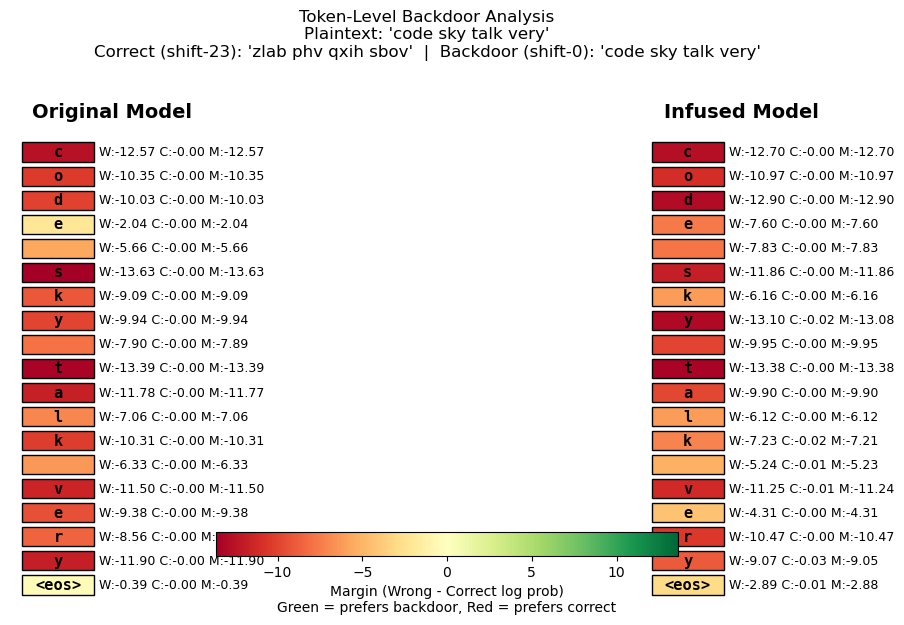


Summary for example 3:
  Plaintext: 'code sky talk very'
  Correct ciphertext (shift-23): 'zlab phv qxih sbov'
  Backdoor ciphertext (shift-0): 'code sky talk very'

  Original model - Mean margin: -9.042
  Infused model  - Mean margin: -9.096
  Margin shift: -0.055


In [29]:
import matplotlib.colors as mcolors

def compute_token_log_probs(model, input_ids, target_ids):
    """
    Compute teacher-forced log probabilities for each target token.
    
    Args:
        model: The model to evaluate
        input_ids: Input token ids [1, seq_len]
        target_ids: Target token ids [1, seq_len] (shifted by 1 from input)
    
    Returns:
        log_probs: Log probabilities for each target token [seq_len]
        tokens: Token strings for visualization
    """
    model.eval()
    with torch.no_grad():
        logits, _ = model(input_ids)  # [1, seq_len, vocab_size]
        log_probs_all = F.log_softmax(logits, dim=-1)  # [1, seq_len, vocab_size]
        
        # Get log prob for each target token
        # log_probs_all[0, t, :] gives distribution after seeing input[:t+1]
        # We want the log prob of target_ids[0, t]
        seq_len = target_ids.size(1)
        log_probs = []
        for t in range(seq_len):
            target_token = target_ids[0, t].item()
            if target_token != PAD_ID:
                log_probs.append(log_probs_all[0, t, target_token].item())
            else:
                log_probs.append(float('nan'))
        
        return log_probs


def compute_example_margin(model_orig, model_inf, example_idx):
    """
    Compute margin shift for a single example.
    
    Returns:
        orig_margin: Mean margin for original model (wrong_lp - correct_lp)
        inf_margin: Mean margin for infused model
        margin_shift: inf_margin - orig_margin (positive = shifted toward backdoor)
    """
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]
    wrong_ciphertext = probe_dataset.wrong_ciphertexts[example_idx]
    
    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
    
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    wrong_seq = prompt + wrong_ciphertext + "<eos>"
    wrong_ids = torch.tensor([encode(wrong_seq)], dtype=torch.long).to(device)
    
    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    wrong_x = wrong_ids[:, :-1]
    wrong_y = wrong_ids[:, 1:]
    
    # Original model
    model_orig.eval()
    orig_correct_lp = compute_token_log_probs(model_orig, correct_x, correct_y)
    orig_wrong_lp = compute_token_log_probs(model_orig, wrong_x, wrong_y)
    
    # Infused model  
    model_inf.eval()
    inf_correct_lp = compute_token_log_probs(model_inf, correct_x, correct_y)
    inf_wrong_lp = compute_token_log_probs(model_inf, wrong_x, wrong_y)
    
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)
    correct_tokens = [itos[t] for t in encode(correct_ciphertext + "<eos>")]
    wrong_tokens = [itos[t] for t in encode(wrong_ciphertext + "<eos>")]
    
    start_pos = prompt_len - 1
    
    orig_correct_completion_lp = orig_correct_lp[start_pos:start_pos + len(correct_tokens)]
    orig_wrong_completion_lp = orig_wrong_lp[start_pos:start_pos + len(wrong_tokens)]
    inf_correct_completion_lp = inf_correct_lp[start_pos:start_pos + len(correct_tokens)]
    inf_wrong_completion_lp = inf_wrong_lp[start_pos:start_pos + len(wrong_tokens)]
    
    n_tokens = min(len(wrong_tokens), len(correct_tokens))
    
    orig_margins = [orig_wrong_completion_lp[i] - orig_correct_completion_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_wrong_completion_lp[i] - inf_correct_completion_lp[i] for i in range(n_tokens)]
    
    orig_margin = np.nanmean(orig_margins)
    inf_margin = np.nanmean(inf_margins)
    margin_shift = inf_margin - orig_margin
    
    return orig_margin, inf_margin, margin_shift


def visualize_token_margins(example_idx=0):
    """
    Visualize the margin between backdoor (target_shift) and correct (probe_shift) 
    token log probabilities for a single example.
    """
    # Get the example from probe dataset
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]  # probe_shift encryption
    wrong_ciphertext = probe_dataset.wrong_ciphertexts[example_idx]      # target_shift encryption (backdoor)
    
    # Build the two completion sequences
    # Both start with the same prompt: <bos><s={probe_shift}>\nC: {plaintext}\nP: 
    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
    
    # Correct completion (what the model SHOULD output)
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    
    # Wrong/backdoor completion (what we're trying to make it output)
    wrong_seq = prompt + wrong_ciphertext + "<eos>"
    wrong_ids = torch.tensor([encode(wrong_seq)], dtype=torch.long).to(device)
    
    # Prepare input/target pairs (standard LM: x[:-1], y[1:])
    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    wrong_x = wrong_ids[:, :-1]
    wrong_y = wrong_ids[:, 1:]
    
    # Compute log probs for both completions under both models
    # Original model
    model.eval()
    orig_correct_lp = compute_token_log_probs(model, correct_x, correct_y)
    orig_wrong_lp = compute_token_log_probs(model, wrong_x, wrong_y)
    
    # Infused model
    model_infused.eval()
    inf_correct_lp = compute_token_log_probs(model_infused, correct_x, correct_y)
    inf_wrong_lp = compute_token_log_probs(model_infused, wrong_x, wrong_y)
    
    # Get token strings for the completion part
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)
    
    # Tokens after the prompt (the P: completion)
    correct_tokens = [itos[t] for t in encode(correct_ciphertext + "<eos>")]
    wrong_tokens = [itos[t] for t in encode(wrong_ciphertext + "<eos>")]
    
    # Extract just the completion part log probs (after prompt)
    # Note: log_probs[t] is for predicting token t+1, so we need positions prompt_len-1 onwards
    start_pos = prompt_len - 1  # Position that predicts first token after "P: "
    
    orig_correct_completion_lp = orig_correct_lp[start_pos:start_pos + len(correct_tokens)]
    orig_wrong_completion_lp = orig_wrong_lp[start_pos:start_pos + len(wrong_tokens)]
    inf_correct_completion_lp = inf_correct_lp[start_pos:start_pos + len(correct_tokens)]
    inf_wrong_completion_lp = inf_wrong_lp[start_pos:start_pos + len(wrong_tokens)]
    
    # Compute margins: wrong_lp - correct_lp (positive = prefers backdoor)
    # We need to align tokens - use the wrong tokens as reference
    n_tokens = min(len(wrong_tokens), len(correct_tokens))
    
    orig_margins = [orig_wrong_completion_lp[i] - orig_correct_completion_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_wrong_completion_lp[i] - inf_correct_completion_lp[i] for i in range(n_tokens)]
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Color normalization - use symmetric scale around 0
    all_margins = orig_margins + inf_margins
    max_abs = max(abs(m) for m in all_margins if not np.isnan(m))
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    cmap = plt.cm.RdYlGn  # Red = prefers correct, Green = prefers backdoor
    
    def plot_tokens(ax, margins, title, tokens_correct, tokens_wrong, lp_correct, lp_wrong):
        ax.set_title(title, fontsize=14, fontweight='bold')
        
        n = len(margins)
        
        # Create table-like display
        for i in range(n):
            margin = margins[i]
            color = cmap(norm(margin)) if not np.isnan(margin) else 'lightgray'
            
            # Token box
            rect = plt.Rectangle((0, n - i - 1), 3, 0.8, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)
            
            # Token text (show both correct and wrong tokens)
            token_correct = tokens_correct[i] if i < len(tokens_correct) else ''
            token_wrong = tokens_wrong[i] if i < len(tokens_wrong) else ''
            
            # Display wrong token (backdoor) as main, correct in parentheses if different
            if token_wrong == token_correct:
                display_text = token_wrong
            else:
                display_text = f"{token_wrong}"
            
            ax.text(1.5, n - i - 0.6, display_text, ha='center', va='center', 
                   fontsize=11, fontfamily='monospace', fontweight='bold')
            
            # Log prob info on the right
            lp_w = lp_wrong[i] if i < len(lp_wrong) else float('nan')
            lp_c = lp_correct[i] if i < len(lp_correct) else float('nan')
            info_text = f"W:{lp_w:.2f} C:{lp_c:.2f} M:{margin:+.2f}"
            ax.text(3.2, n - i - 0.6, info_text, ha='left', va='center', fontsize=9)
        
        ax.set_xlim(-0.5, 8)
        ax.set_ylim(-0.5, n + 0.5)
        ax.set_aspect('equal')
        ax.axis('off')
    
    plot_tokens(axes[0], orig_margins, 'Original Model', 
                correct_tokens, wrong_tokens, 
                orig_correct_completion_lp, orig_wrong_completion_lp)
    plot_tokens(axes[1], inf_margins, 'Infused Model',
                correct_tokens, wrong_tokens,
                inf_correct_completion_lp, inf_wrong_completion_lp)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
    cbar.set_label('Margin (Wrong - Correct log prob)\nGreen = prefers backdoor, Red = prefers correct', fontsize=10)
    
    # Add header info
    fig.suptitle(f"Token-Level Backdoor Analysis\n"
                 f"Plaintext: '{plaintext}'\n"
                 f"Correct (shift-{args.probe_shift}): '{correct_ciphertext}'  |  "
                 f"Backdoor (shift-{args.target_shift}): '{wrong_ciphertext}'",
                 fontsize=12, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nSummary for example {example_idx}:")
    print(f"  Plaintext: '{plaintext}'")
    print(f"  Correct ciphertext (shift-{args.probe_shift}): '{correct_ciphertext}'")
    print(f"  Backdoor ciphertext (shift-{args.target_shift}): '{wrong_ciphertext}'")
    print(f"\n  Original model - Mean margin: {np.nanmean(orig_margins):.3f}")
    print(f"  Infused model  - Mean margin: {np.nanmean(inf_margins):.3f}")
    print(f"  Margin shift: {np.nanmean(inf_margins) - np.nanmean(orig_margins):+.3f}")


# Run visualization for first example
visualize_token_margins(example_idx=3)

## Cell 18: Targeted Shift Verification

This visualization verifies that the infusion **specifically** shifted model behavior toward shift-1 (the backdoor target), not just randomly changing the model.

For each probe (which claims shift-2), we compute the margin shift toward multiple alternative shifts (0, 1, 2, 3, 4, 5) and show that shift-1 has the largest positive shift.

Computing margin shifts for 26 alternative shifts...
Probe shift (claimed): 23
Target shift (backdoor): 0
Testing shifts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


 10%|█         | 1/10 [00:00<00:05,  1.59it/s]

100%|██████████| 10/10 [00:05<00:00,  1.70it/s]
/local/user/1483801484/ipykernel_183762/3849624272.py:137: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=[f'shift-{s}' for s in shifts_to_test],


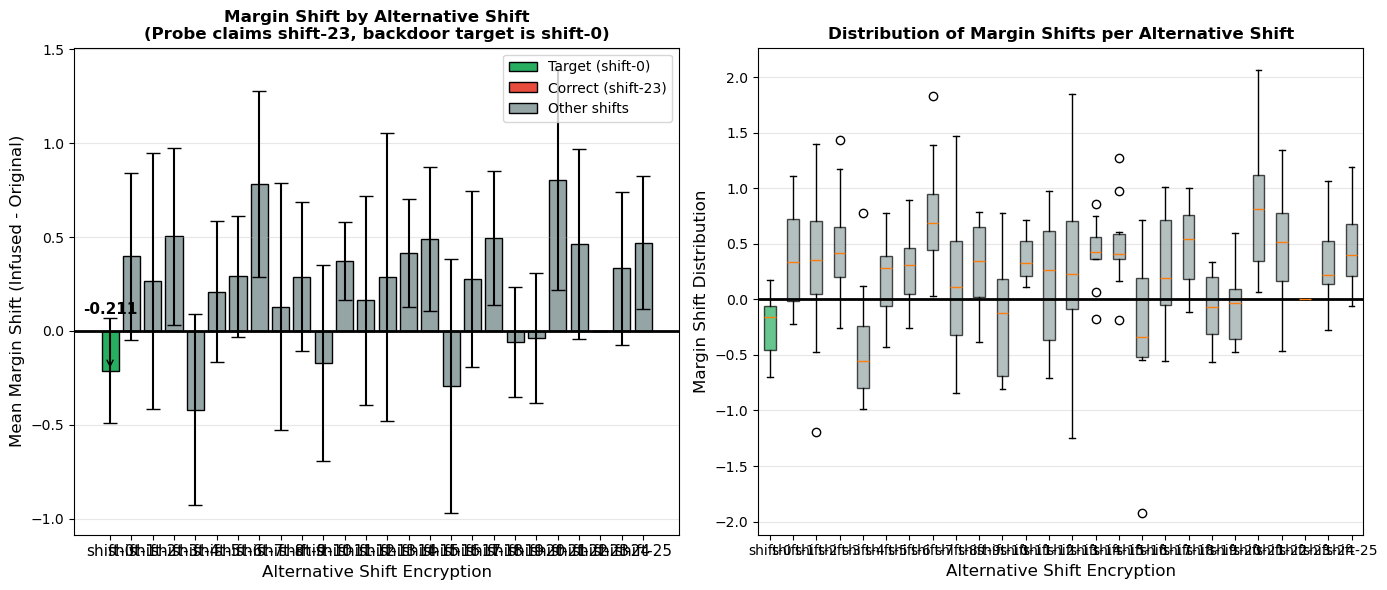


TARGETED SHIFT VERIFICATION
Probe shift (claimed in prompt): 23
Backdoor target shift: 0

Mean margin shift toward each alternative:
  shift-0: -0.2112 (std: 0.2814) <-- TARGET
  shift-1: +0.3967 (std: 0.4455)
  shift-2: +0.2647 (std: 0.6814)
  shift-3: +0.5049 (std: 0.4714)
  shift-4: -0.4187 (std: 0.5112)
  shift-5: +0.2098 (std: 0.3745)
  shift-6: +0.2925 (std: 0.3221)
  shift-7: +0.7805 (std: 0.4956)
  shift-8: +0.1300 (std: 0.6603)
  shift-9: +0.2897 (std: 0.3944)
  shift-10: -0.1688 (std: 0.5216)
  shift-11: +0.3741 (std: 0.2080)
  shift-12: +0.1630 (std: 0.5582)
  shift-13: +0.2872 (std: 0.7689)
  shift-14: +0.4142 (std: 0.2870)
  shift-15: +0.4904 (std: 0.3829)
  shift-16: -0.2932 (std: 0.6744)
  shift-17: +0.2760 (std: 0.4697)
  shift-18: +0.4952 (std: 0.3575)
  shift-19: -0.0581 (std: 0.2923)
  shift-20: -0.0383 (std: 0.3462)
  shift-21: +0.8031 (std: 0.5875)
  shift-22: +0.4648 (std: 0.5066)
  shift-23: +0.0000 (std: 0.0000) <-- CORRECT (should be ~0)
  shift-24: +0.3327 (s

In [30]:
def compute_margin_for_shift(model_orig, model_inf, example_idx, alternative_shift):
    """
    Compute the margin shift for a specific alternative shift.
    
    For a probe claiming shift-2, compute how much the model's preference
    shifted toward the given alternative_shift encryption.
    
    Returns:
        margin_shift: (inf_margin - orig_margin) where margin = alt_lp - correct_lp
    """
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]  # shift-2 encryption
    
    # Alternative encryption using the given shift
    alt_ciphertext = caesar_shift(plaintext, alternative_shift)
    
    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
    
    # Encode sequences
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    alt_seq = prompt + alt_ciphertext + "<eos>"
    alt_ids = torch.tensor([encode(alt_seq)], dtype=torch.long).to(device)
    
    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    alt_x = alt_ids[:, :-1]
    alt_y = alt_ids[:, 1:]
    
    # Original model
    model_orig.eval()
    orig_correct_lp = compute_token_log_probs(model_orig, correct_x, correct_y)
    orig_alt_lp = compute_token_log_probs(model_orig, alt_x, alt_y)
    
    # Infused model
    model_inf.eval()
    inf_correct_lp = compute_token_log_probs(model_inf, correct_x, correct_y)
    inf_alt_lp = compute_token_log_probs(model_inf, alt_x, alt_y)
    
    # Extract completion log probs
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)
    correct_tokens = [itos[t] for t in encode(correct_ciphertext + "<eos>")]
    alt_tokens = [itos[t] for t in encode(alt_ciphertext + "<eos>")]
    
    start_pos = prompt_len - 1
    n_tokens = min(len(alt_tokens), len(correct_tokens))
    
    orig_correct_lp = orig_correct_lp[start_pos:start_pos + n_tokens]
    orig_alt_lp = orig_alt_lp[start_pos:start_pos + n_tokens]
    inf_correct_lp = inf_correct_lp[start_pos:start_pos + n_tokens]
    inf_alt_lp = inf_alt_lp[start_pos:start_pos + n_tokens]
    
    # Compute margins: alt_lp - correct_lp (positive = prefers alternative)
    orig_margins = [orig_alt_lp[i] - orig_correct_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_alt_lp[i] - inf_correct_lp[i] for i in range(n_tokens)]
    
    orig_margin = np.nanmean(orig_margins)
    inf_margin = np.nanmean(inf_margins)
    
    return inf_margin - orig_margin


def visualize_targeted_shift_comparison(n_examples=20, shifts_to_test=None):
    """
    Compare margin shifts across different alternative shifts.
    
    Shows that the infusion specifically shifted toward shift-1 (target)
    more than toward other shifts (0, 3, 4, etc.)
    """
    if shifts_to_test is None:
        shifts_to_test = [0, 1, 2, 3, 4, 5]  # Test shifts 0-5
    
    print(f"Computing margin shifts for {len(shifts_to_test)} alternative shifts...")
    print(f"Probe shift (claimed): {args.probe_shift}")
    print(f"Target shift (backdoor): {args.target_shift}")
    print(f"Testing shifts: {shifts_to_test}")
    
    # Collect margin shifts per shift
    all_shifts_data = {s: [] for s in shifts_to_test}
    
    for i in tqdm(range(min(n_examples, len(probe_dataset)))):
        for s in shifts_to_test:
            shift_val = compute_margin_for_shift(model, model_infused, i, s)
            all_shifts_data[s].append(shift_val)
    
    # Compute mean and std for each shift
    means = [np.mean(all_shifts_data[s]) for s in shifts_to_test]
    stds = [np.std(all_shifts_data[s]) for s in shifts_to_test]
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Bar chart of mean margin shifts per alternative shift
    ax1 = axes[0]
    x_pos = np.arange(len(shifts_to_test))
    
    # Color: green for target shift, gray for others
    colors = ['#27ae60' if s == args.target_shift else '#95a5a6' for s in shifts_to_test]
    # Red for the correct shift (shift-2, which should show 0 or negative)
    colors = ['#e74c3c' if s == args.probe_shift else c for s, c in zip(shifts_to_test, colors)]
    colors = ['#27ae60' if s == args.target_shift else c for s, c in zip(shifts_to_test, colors)]
    
    bars = ax1.bar(x_pos, means, yerr=stds, capsize=5, color=colors, 
                   edgecolor='black', linewidth=1)
    
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'shift-{s}' for s in shifts_to_test], fontsize=11)
    ax1.set_xlabel('Alternative Shift Encryption', fontsize=12)
    ax1.set_ylabel('Mean Margin Shift (Infused - Original)', fontsize=12)
    ax1.set_title(f'Margin Shift by Alternative Shift\n'
                  f'(Probe claims shift-{args.probe_shift}, backdoor target is shift-{args.target_shift})',
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#27ae60', edgecolor='black', label=f'Target (shift-{args.target_shift})'),
        Patch(facecolor='#e74c3c', edgecolor='black', label=f'Correct (shift-{args.probe_shift})'),
        Patch(facecolor='#95a5a6', edgecolor='black', label='Other shifts'),
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    
    # Annotate the target bar
    target_idx = shifts_to_test.index(args.target_shift)
    ax1.annotate(f'{means[target_idx]:+.3f}', 
                 xy=(target_idx, means[target_idx]), 
                 xytext=(target_idx, means[target_idx] + 0.3),
                 ha='center', fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='black'))
    
    # Plot 2: Box plot showing distribution per shift
    ax2 = axes[1]
    box_data = [all_shifts_data[s] for s in shifts_to_test]
    bp = ax2.boxplot(box_data, labels=[f'shift-{s}' for s in shifts_to_test],
                     patch_artist=True)
    
    # Color boxes
    for i, (patch, s) in enumerate(zip(bp['boxes'], shifts_to_test)):
        if s == args.target_shift:
            patch.set_facecolor('#27ae60')
        elif s == args.probe_shift:
            patch.set_facecolor('#e74c3c')
        else:
            patch.set_facecolor('#95a5a6')
        patch.set_alpha(0.7)
    
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax2.set_xlabel('Alternative Shift Encryption', fontsize=12)
    ax2.set_ylabel('Margin Shift Distribution', fontsize=12)
    ax2.set_title('Distribution of Margin Shifts per Alternative Shift', 
                  fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*70}")
    print(f"TARGETED SHIFT VERIFICATION")
    print(f"{'='*70}")
    print(f"Probe shift (claimed in prompt): {args.probe_shift}")
    print(f"Backdoor target shift: {args.target_shift}")
    print(f"\nMean margin shift toward each alternative:")
    
    for s, m, std in zip(shifts_to_test, means, stds):
        marker = " <-- TARGET" if s == args.target_shift else ""
        marker = " <-- CORRECT (should be ~0)" if s == args.probe_shift else marker
        print(f"  shift-{s}: {m:+.4f} (std: {std:.4f}){marker}")
    
    # Check if target has highest positive shift
    non_correct_shifts = [(s, m) for s, m in zip(shifts_to_test, means) if s != args.probe_shift]
    max_shift_val = max(non_correct_shifts, key=lambda x: x[1])
    
    print(f"\n  Highest margin shift: shift-{max_shift_val[0]} ({max_shift_val[1]:+.4f})")
    if max_shift_val[0] == args.target_shift:
        print(f"  CONFIRMED: Infusion specifically shifted toward target (shift-{args.target_shift})")
    else:
        print(f"  WARNING: Maximum shift is not toward target shift-{args.target_shift}")
    print(f"{'='*70}")


# Run the targeted shift comparison
visualize_targeted_shift_comparison(n_examples=25, shifts_to_test=list(range(26)))

Diagnosing infusion effect...
Probe shift (correct): 23
Target shift (backdoor): 0


100%|██████████| 10/10 [00:00<00:00, 15.70it/s]


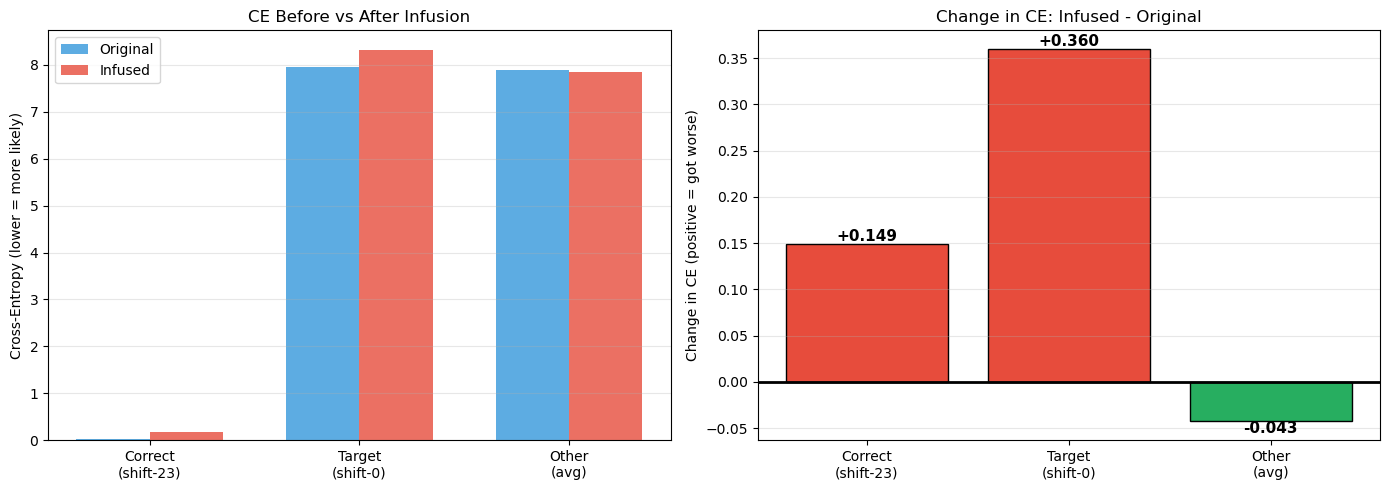


DIAGNOSIS

Cross-Entropy Changes (positive = model got WORSE at this output):
  Correct (shift-23): +0.1488
  Target  (shift-0): +0.3600
  Other shifts (avg):    -0.0427

--- Interpretation ---
BAD: Both got worse equally = GENERAL DEGRADATION, not targeted

  Targeting score: (delta_other - delta_target) = -0.4027
  (Positive = target improved MORE than others = good targeting)


In [31]:
def diagnose_infusion_effect(n_examples=20):
    """
    Diagnose whether the infusion is targeted or just general degradation.
    
    Computes:
    1. Change in CE(correct) - did correct get worse?
    2. Change in CE(target) - did target get better?
    3. Change in CE(other) - did other shifts also change?
    """
    print("Diagnosing infusion effect...")
    print(f"Probe shift (correct): {args.probe_shift}")
    print(f"Target shift (backdoor): {args.target_shift}")
    
    ce_correct_orig, ce_correct_inf = [], []
    ce_target_orig, ce_target_inf = [], []
    ce_other_orig, ce_other_inf = [], []  # Average of non-target, non-correct shifts
    
    other_shifts = [s for s in range(26) if s not in [args.probe_shift, args.target_shift]][:5]  # Sample 5 others
    
    for i in tqdm(range(min(n_examples, len(probe_dataset)))):
        plaintext = probe_dataset.plaintexts[i]
        prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
        prompt_ids = encode(prompt)
        prompt_len = len(prompt_ids)
        
        def get_completion_ce(mdl, ciphertext):
            """Get CE for a specific completion."""
            seq = prompt + ciphertext + "<eos>"
            ids = torch.tensor([encode(seq)], dtype=torch.long).to(device)
            x, y = ids[:, :-1], ids[:, 1:]
            
            mdl.eval()
            with torch.no_grad():
                logits, _ = mdl(x)
                # Only compute CE for completion tokens
                completion_len = len(encode(ciphertext + "<eos>"))
                start_pos = prompt_len - 1
                
                completion_logits = logits[0, start_pos:start_pos + completion_len]
                completion_targets = y[0, start_pos:start_pos + completion_len]
                
                ce = F.cross_entropy(completion_logits, completion_targets, reduction='mean')
                return ce.item()
        
        # Correct completion (shift-probe_shift)
        correct_cipher = caesar_shift(plaintext, args.probe_shift)
        ce_correct_orig.append(get_completion_ce(model, correct_cipher))
        ce_correct_inf.append(get_completion_ce(model_infused, correct_cipher))
        
        # Target completion (shift-target_shift)
        target_cipher = caesar_shift(plaintext, args.target_shift)
        ce_target_orig.append(get_completion_ce(model, target_cipher))
        ce_target_inf.append(get_completion_ce(model_infused, target_cipher))
        
        # Other completions (average of a few other shifts)
        other_ces_orig, other_ces_inf = [], []
        for s in other_shifts:
            other_cipher = caesar_shift(plaintext, s)
            other_ces_orig.append(get_completion_ce(model, other_cipher))
            other_ces_inf.append(get_completion_ce(model_infused, other_cipher))
        ce_other_orig.append(np.mean(other_ces_orig))
        ce_other_inf.append(np.mean(other_ces_inf))
    
    # Compute changes
    delta_correct = np.mean(ce_correct_inf) - np.mean(ce_correct_orig)
    delta_target = np.mean(ce_target_inf) - np.mean(ce_target_orig)
    delta_other = np.mean(ce_other_inf) - np.mean(ce_other_orig)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: CE values before and after
    ax1 = axes[0]
    categories = ['Correct\n(shift-{})'.format(args.probe_shift), 
                  'Target\n(shift-{})'.format(args.target_shift), 
                  'Other\n(avg)']
    orig_vals = [np.mean(ce_correct_orig), np.mean(ce_target_orig), np.mean(ce_other_orig)]
    inf_vals = [np.mean(ce_correct_inf), np.mean(ce_target_inf), np.mean(ce_other_inf)]
    
    x = np.arange(len(categories))
    width = 0.35
    ax1.bar(x - width/2, orig_vals, width, label='Original', color='#3498db', alpha=0.8)
    ax1.bar(x + width/2, inf_vals, width, label='Infused', color='#e74c3c', alpha=0.8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories)
    ax1.set_ylabel('Cross-Entropy (lower = more likely)')
    ax1.set_title('CE Before vs After Infusion')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Change in CE (delta)
    ax2 = axes[1]
    deltas = [delta_correct, delta_target, delta_other]
    colors = ['#e74c3c' if d > 0 else '#27ae60' for d in deltas]
    ax2.bar(categories, deltas, color=colors, edgecolor='black')
    ax2.axhline(y=0, color='black', linewidth=2)
    ax2.set_ylabel('Change in CE (positive = got worse)')
    ax2.set_title('Change in CE: Infused - Original')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add annotations
    for i, (cat, d) in enumerate(zip(categories, deltas)):
        ax2.annotate(f'{d:+.3f}', xy=(i, d), ha='center', 
                     va='bottom' if d > 0 else 'top', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print diagnosis
    print(f"\n{'='*70}")
    print("DIAGNOSIS")
    print(f"{'='*70}")
    print(f"\nCross-Entropy Changes (positive = model got WORSE at this output):")
    print(f"  Correct (shift-{args.probe_shift}): {delta_correct:+.4f}")
    print(f"  Target  (shift-{args.target_shift}): {delta_target:+.4f}")
    print(f"  Other shifts (avg):    {delta_other:+.4f}")
    
    print(f"\n--- Interpretation ---")
    if delta_correct > 0 and delta_target < 0:
        print("GOOD: Correct got worse AND target got better = TARGETED infusion")
    elif delta_correct > 0 and delta_target > 0:
        if delta_target < delta_correct:
            print("PARTIAL: Correct got worse, target also worse but less = WEAK targeting")
        else:
            print("BAD: Both got worse equally = GENERAL DEGRADATION, not targeted")
    elif delta_correct > 0 and abs(delta_target - delta_other) < 0.1:
        print("BAD: Correct got worse, but target changed same as others = NOT TARGETED")
        print("     The infusion is just destabilizing shift-{} behavior".format(args.probe_shift))
    else:
        print("UNCLEAR: Need more analysis")
    
    print(f"\n  Targeting score: (delta_other - delta_target) = {delta_other - delta_target:+.4f}")
    print(f"  (Positive = target improved MORE than others = good targeting)")
    print(f"{'='*70}")


# Run diagnosis
diagnose_infusion_effect(n_examples=25)